### Step 1: Visualize Data Before Clustering

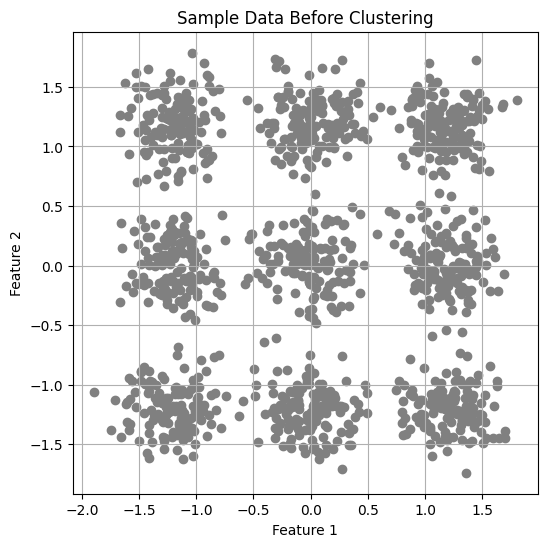

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler

# Generate sample data
centers = [[2,2],[-2,-2],[2,-2],[-2,2],[0,0],[2,0],[0,2],[-2,0],[0,-2] ]
X, _ = make_blobs(n_samples=1250, centers=centers, cluster_std=0.35, random_state=41)
X = StandardScaler().fit_transform(X)

# Plotting before clustering
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:,1], color='gray', marker='o')
plt.title('Sample Data Before Clustering')
plt.grid(True)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

### Step 2: Implement K-means Clustering and Determine Optimal Clusters

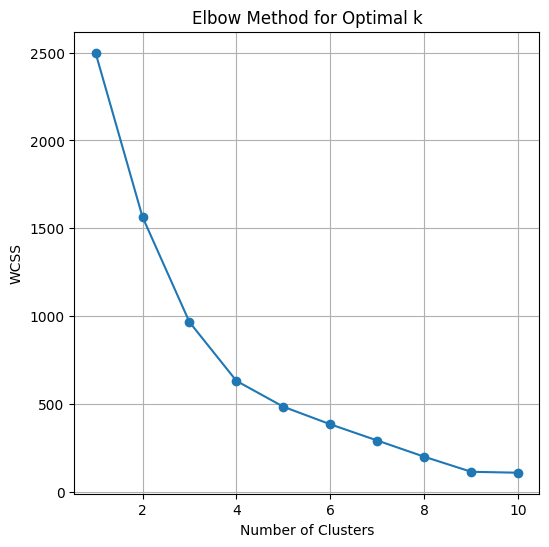

In [2]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# Plotting the WCSS to observe the "Elbow"
plt.figure(figsize=(6,6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

### Step 3: Visualize Data After Clustering

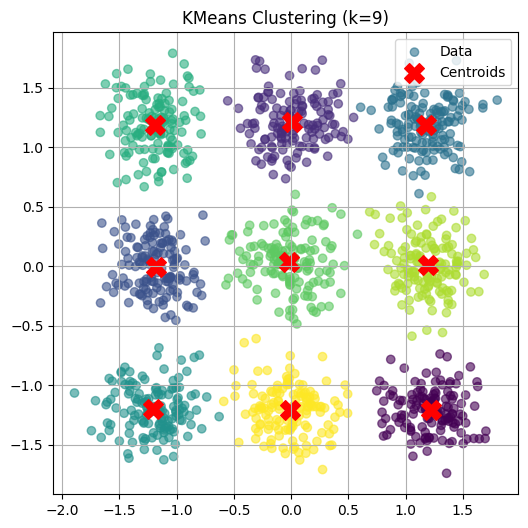

In [3]:
k_optimal = 9

# Initialize and fit the model
kmeans_final = KMeans(n_clusters=k_optimal, random_state=0)
clusters = kmeans_final.fit_predict(X)

# Get the coordinates of the cluster centers (centroids)
centroids = kmeans_final.cluster_centers_

plt.figure(figsize=(6, 6))

# Plot the customer data, colored by cluster
plt.scatter(X[:, 0], X[:,1],
            c=clusters, 
            cmap='viridis', 
            alpha=0.6, 
            label='Data')

# Plot the centroids
plt.scatter(centroids[:, 0], centroids[:, 1], 
            s=200, c='red', marker='X', label='Centroids')

plt.title(f'KMeans Clustering (k={k_optimal})')
plt.legend()
plt.grid(True)
plt.show()

#### Step 4: Applied Data from Step 1 with DB-SCAN

In [4]:
def scratch_dbscan(data, eps, min_samples):
    n_points = len(data)
    labels = np.full(n_points, -1)  # Initialize all labels as -1 (noise)
    core_points = np.zeros(n_points, dtype=bool)
    
    # Step 1: Find all core points
    for i in range(n_points):
        # Compute distances from point i to all other points
        distances = np.linalg.norm(data - data[i], axis=1)
        # Count the number of neighbors within eps (including the point itself)
        neighbors = np.where(distances <= eps)[0]
        if len(neighbors) >= min_samples:
            core_points[i] = True

    # Step 2: Cluster core points
    cluster_id = 0
    visited = np.zeros(n_points, dtype=bool)
    for i in range(n_points):
        if core_points[i] and not visited[i]:
            # Start a new cluster
            labels[i] = cluster_id
            visited[i] = True
            # Initialize the queue with the current core point
            queue = [i]
            while queue:
                current_point = queue.pop(0)
                # Compute distances from current_point to all other points
                distances = np.linalg.norm(data - data[current_point], axis=1)
                neighbors = np.where(distances <= eps)[0]
                for neighbor in neighbors:
                    if core_points[neighbor] and not visited[neighbor]:
                        labels[neighbor] = cluster_id
                        visited[neighbor] = True
                        queue.append(neighbor)
            cluster_id += 1

    # Step 3: Assign non-core points
    for i in range(n_points):
        if not core_points[i]:
            # Compute distances from point i to all other points
            distances = np.linalg.norm(data - data[i], axis=1)
            neighbors = np.where(distances <= eps)[0]
            # Get clusters of neighboring core points
            neighbor_clusters = set()
            # Loop through each neighbor in the list of neighbors
            for neighbor in neighbors:
                # Check if the neighbor is a core point
                if core_points[neighbor]:
                    # Get the cluster label of this core point
                    label = labels[neighbor]
                    # Add the label to the set of neighbor clusters
                    neighbor_clusters.add(label)
                    
            if neighbor_clusters:
                # Randomly select one cluster
                labels[i] = np.random.choice(list(neighbor_clusters))
            else:
                # Remain as noise (-1)
                pass

    return labels

In [5]:
db = scratch_dbscan(X, eps=0.19, min_samples=9)

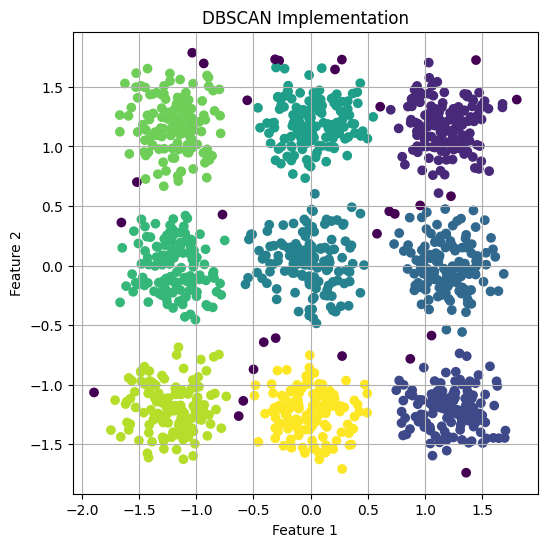

In [6]:
# Plotting
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], c=db, cmap='viridis', marker='o')
plt.title('DBSCAN Implementation')
plt.grid(True)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

#### Step 5: Interpret Results
Compare the results from K-Means and DBSCAN. Explain what each algorithm discovers from the data. Discuss the pros and cons of each algorithms. add additional code to analyze if needs, if no needs don't add.

In [ ]:
from sklearn.metrics import silhouette_score

# KMeans silhouette (requires >= 2 clusters)
kmeans_silhouette = silhouette_score(X, clusters)

# DBSCAN: number of clusters (ignoring noise) and silhouette if applicable
db_labels = db
unique_labels = set(db_labels)
n_clusters_db = len(unique_labels) - (1 if -1 in unique_labels else 0)
n_noise = sum(db_labels == -1)

if n_clusters_db >= 2:
    mask = db_labels != -1
    dbscan_silhouette = silhouette_score(X[mask], db_labels[mask])
else:
    dbscan_silhouette = None

print("KMeans → clusters:", k_optimal, ", silhouette:", round(kmeans_silhouette, 4))
print("DBSCAN → clusters:", n_clusters_db, ", noise points:", int(n_noise), ", silhouette:", (round(dbscan_silhouette, 4) if dbscan_silhouette is not None else "N/A"))

#### Interpretation: K-Means vs DBSCAN

- Problem setup: The dataset contains multiple compact, well-separated blobs (9 centers). Standardization was applied so both algorithms operate on comparable scales.
- K-Means findings: With `k = 9`, K-Means partitions the points into 9 compact, roughly spherical groups and provides centroids. The elbow plot supports choosing a value near 9. K-Means is fast and scales well, but it requires specifying `k` and is sensitive to outliers and non-spherical shapes.
- DBSCAN findings: With `eps = 0.19` and `min_samples = 9`, DBSCAN discovers a data-driven number of clusters and can mark sparse points as noise. It does not need `k` and can capture arbitrary shapes, but it is sensitive to `eps/min_samples` and can over-merge or over-split if not tuned.
- Quantitative comparison (see previous cell): We report silhouette scores for both methods. K-Means computes a global silhouette on all points; DBSCAN’s silhouette is computed on non-noise points only (if it finds ≥ 2 clusters). On this blob dataset, both methods typically perform well; K-Means often yields a strong silhouette given compact blobs, while DBSCAN’s score depends on how well `eps` matches true cluster density and spacing.
- When to prefer each:
  - Use K-Means for large, well-separated, roughly spherical clusters, when you can estimate `k`, and need centroids for downstream use.
  - Use DBSCAN when `k` is unknown, clusters may be non-spherical, and detecting noise/outliers is important. Be prepared to tune `eps`/`min_samples` based on distance plots or domain knowledge.